QAOA-GPT embedding comparison

In [2]:
import random
import numpy as np
import torch

import pandas as pd
import matplotlib.pyplot as plt

from src.model_interface import QAOA_GPT

from src.utils import generate_er_graphs
from src.adapt_utils import compute_metrics

pd.set_option("display.max_columns", None)

In [3]:
# SEED
# ------------------------

SEED = 1337

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
# CONFIG
# ------------------------

N_GRAPHS = 5
N_NODES = 10

N_SAMPLES = 5
MAX_TOKENS = 150


EMBEDDINGS = ["feather", "netlsd", "gnn"]
MODELS = ["gpt", "llama"]


EMBEDDING_NAMES = dict(
    feather="Feather",
    netlsd="NetLSD",
    gnn="GNN",
)

MODEL_NAMES = dict(
    gpt="nanoGPT",
    llama="LLaMA",
)

In [8]:
# PATH CONFIG
# ------------------------

PATHS = dict(

    gpt=dict(
        feather=(
            "nanoGPT/out-10_nodes_feather/gpt_ckpt_3500_feather_ar_0_96305__er_0_0.pt",
            "nanoGPT/data/10_nodes_feather",
        ),
        netlsd=(
            "nanoGPT/out-10_nodes_netlsd/gpt_ckpt_3500_netlsd_ar_0_95477__er_0_0.pt",
            "nanoGPT/data/10_nodes_netlsd",
        ),
        gnn=(
            "nanoGPT/out-10_nodes_gnn/gpt_ckpt_4500_gnn_ar_0_96316__er_0_0.pt",
            "nanoGPT/data/10_nodes_gnn",
        ),
    ),

    llama=dict(
        feather=(
            "nanoGPT/out-10_nodes_feather/llama_ckpt_6500_feather_ar_0_93013__er_0_12.pt",
            "nanoGPT/data/10_nodes_feather",
        ),
        netlsd=(
            "nanoGPT/out-10_nodes_netlsd/llama_ckpt_6000_netlsd_ar_0_9436__er_0_026.pt",
            "nanoGPT/data/10_nodes_netlsd",
        ),
        gnn=(
            "nanoGPT/out-10_nodes_gnn/llama_ckpt_5500_gnn_ar_0_924__er_0_006.pt",
            "nanoGPT/data/10_nodes_gnn",
        ),
    ),

)

In [9]:
# RUN ONE
# ------------------------

def run_one(model, embedding):

    print(f"Running {model} + {embedding}")

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    ckpt, data = PATHS[model][embedding]

    qaoa = QAOA_GPT(
        model_ckpt=ckpt,
        data_dir=data,
        temp_folder="temp_data",
    )

    graphs = generate_er_graphs(
        N_GRAPHS,
        N_NODES,
    )

    df = qaoa.generate_circ_from_nx(
        graphs,
        num_samples=N_SAMPLES,
        max_new_tokens=MAX_TOKENS,
        temperature=0.1,
        top_k=200,
    )

    df_eval = qaoa.eval_circ_df_jl(df)

    ar, err, layers = compute_metrics(df_eval)

    return dict(
        model=model,
        embedding=embedding,
        AR=ar,
        layers=layers,
        error=err,
    )

In [10]:
# RUN ALL
# ------------------------

results = []

for model in MODELS:
    for emb in EMBEDDINGS:

        res = run_one(model, emb)

        results.append(res)

result_df = pd.DataFrame(results)

result_df

Running gpt + feather

Model type: gpt
Pool type: qaoa_double_pool
Embedding method: feather
Number of nodes: 10
Initiating nanoGPT model with padding support
number of parameters: 11.68M


Preparing graphs...:   0%|          | 0/5 [00:00<?, ?it/s]

Restricted license - for non-production use only - expires 2027-11-29


Preparing graphs...: 100%|██████████| 5/5 [00:00<00:00, 89.71it/s]


Performing feather embedding


...

GNN: 100%|██████████| 5/5 [00:00<00:00, 191.11it/s]


GNN shape: (5, 500)


Inference. Current batch: n_edges: 31, n_graphs: 1: 100%|██████████| 5/5 [00:04<00:00,  1.22it/s]



===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-03__22_29_09_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-04-03__22_29_09_df_jl.json 10 qaoa_double_pool


Julia return code: 0


,model,embedding,AR,layers,error
0,gpt,feather,0.96941,8.96,0.0
1,gpt,netlsd,0.96765,9.84,0.0
2,gpt,gnn,0.91575,11.12,0.6
3,llama,feather,0.94120,13.40,0.0
4,llama,netlsd,0.95934,10.88,0.0
5,llama,gnn,0.71000,14.40,0.0


In [11]:
# FORMAT TABLE
# ------------------------

result_df["model"] = result_df["model"].map(MODEL_NAMES)
result_df["embedding"] = result_df["embedding"].map(EMBEDDING_NAMES)

result_df

,model,embedding,AR,layers,error
0,nanoGPT,Feather,0.96941,8.96,0.0
1,nanoGPT,NetLSD,0.96765,9.84,0.0
2,nanoGPT,GNN,0.91575,11.12,0.6
3,LLaMA,Feather,0.94120,13.40,0.0
4,LLaMA,NetLSD,0.95934,10.88,0.0
5,LLaMA,GNN,0.71000,14.40,0.0


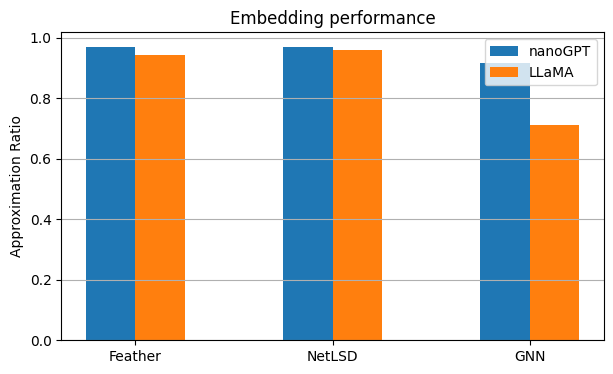

In [12]:
# PLOT AR (GROUPED)
# ------------------------

def plot_ar(df):

    fig, ax = plt.subplots(figsize=(7, 4))

    width = 0.25

    x = np.arange(len(EMBEDDINGS))

    for i, model in enumerate(df["model"].unique()):

        sub = df[df["model"] == model]

        ax.bar(
            x + i * width,
            sub["AR"],
            width,
            label=model,
        )

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(df["embedding"].unique())

    ax.set_ylabel("Approximation Ratio")
    ax.set_title("Embedding performance")

    ax.legend()
    ax.grid(True, axis="y")

    plt.show()


plot_ar(result_df)

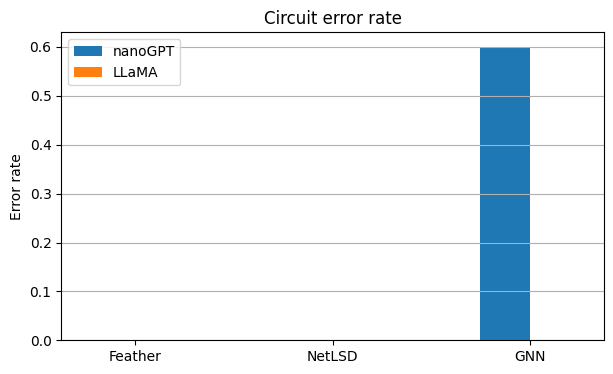

In [13]:
# PLOT ERROR
# ------------------------

def plot_error(df):

    fig, ax = plt.subplots(figsize=(7, 4))

    width = 0.25
    x = np.arange(len(EMBEDDINGS))

    for i, model in enumerate(df["model"].unique()):

        sub = df[df["model"] == model]

        ax.bar(
            x + i * width,
            sub["error"],
            width,
            label=model,
        )

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(df["embedding"].unique())

    ax.set_ylabel("Error rate")
    ax.set_title("Circuit error rate")

    ax.legend()
    ax.grid(True, axis="y")

    plt.show()


plot_error(result_df)

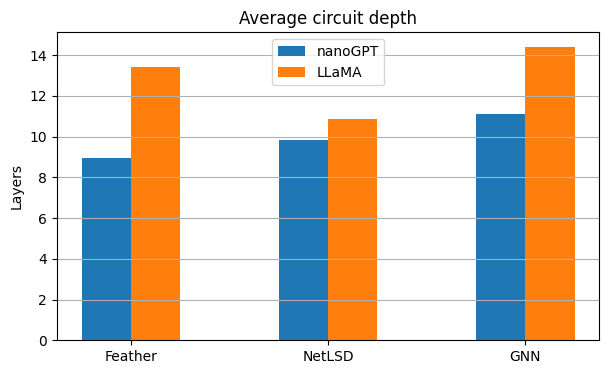

In [14]:
# PLOT LAYERS
# ------------------------

def plot_layers(df):

    fig, ax = plt.subplots(figsize=(7, 4))

    width = 0.25
    x = np.arange(len(EMBEDDINGS))

    for i, model in enumerate(df["model"].unique()):

        sub = df[df["model"] == model]

        ax.bar(
            x + i * width,
            sub["layers"],
            width,
            label=model,
        )

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(df["embedding"].unique())

    ax.set_ylabel("Layers")
    ax.set_title("Average circuit depth")

    ax.legend()
    ax.grid(True, axis="y")

    plt.show()


plot_layers(result_df)

In [15]:
# REPORT
# ------------------------

def report(df):

    print("====== REPORT ======")

    for model in df["model"].unique():

        print("\nMODEL:", model)

        sub = df[df["model"] == model]

        best = sub.sort_values(
            "AR",
            ascending=False,
        ).iloc[0]

        print("Best embedding:", best["embedding"])
        print("Best AR:", best["AR"])

        print("\nTable:")
        print(sub)


report(result_df)

====== REPORT ======

MODEL: nanoGPT
Best embedding: Feather
Best AR: 0.96941

Table:
     model embedding       AR  layers  error
0  nanoGPT   Feather  0.96941    8.96    0.0
1  nanoGPT    NetLSD  0.96765    9.84    0.0
2  nanoGPT       GNN  0.91575   11.12    0.6

MODEL: LLaMA
Best embedding: NetLSD
Best AR: 0.95934

Table:
   model embedding       AR  layers  error
3  LLaMA   Feather  0.94120   13.40    0.0
4  LLaMA    NetLSD  0.95934   10.88    0.0
5  LLaMA       GNN  0.71000   14.40    0.0
